In [3]:
# print("Cell Initiated")

# import numpy as np
# import pandas as pd
# import pickle
# import matplotlib.pyplot as plt
# import os

# # =============================================================================
# # GLOBAL PLOT STYLE — matches existing PoC notebooks
# # =============================================================================
# plt.rcParams.update({
#     'font.size': 18,
#     'axes.titlesize': 24,
#     'axes.labelsize': 22,
#     'xtick.labelsize': 18,
#     'ytick.labelsize': 18,
#     'legend.fontsize': 16,
#     'figure.titlesize': 26,
# })

# # =============================================================================
# # COLORS — consistent with Proof_Of_Concept_Pipeline notebooks
# # =============================================================================
# MAIN_COLOR   = '#2E86AB'   # blue — primary data
# TRUTH_COLOR  = '#C44536'   # retro red — S1 truth lines
# CORNER_COLOR = '#D4733C'   # burnt orange — second series / corner plots
# CDM_COLOR    = '#1ABC9C'   # teal — CDM
# NADLER_COLOR = '#F39C12'   # amber — Nadler reference

# COLORS = {
#     'CDM':       ('#1ABC9C', '#117A65'),
#     'WDM_5keV':  ('#8E44AD', '#5B2C6F'),
#     'WDM_6keV':  ('#D35400', '#873600'),
#     'WDM_7keV':  ('#C0392B', '#7B241C'),
#     'WDM_8keV':  ('#E74C3C', '#922B21'),
#     'WDM_9keV':  ('#E67E22', '#A04000'),
#     'WDM_10keV': ('#F39C12', '#B9770E'),
#     'WDM_11keV': ('#AF7AC5', '#7D3C98'),
#     'WDM_12keV': ('#9B59B6', '#6C3483'),
#     'WDM_13keV': ('#5DADE2', '#2874A6'),
#     'WDM_14keV': ('#3498DB', '#21618C'),
#     'WDM_15keV': ('#2ECC71', '#1D8348'),
# }

# # =============================================================================
# # CONFIGURATION
# # =============================================================================
# # Update this path to wherever you SCP'd the pkl files
# PKL_DIR = './'  # <-- adjust if needed

# COSMO_NAMES = ['CDM'] + [f'WDM_{m}keV' for m in [5,6,7,8,9,10,11,12,13,14,15]]
# MWDM_VALUES = [100.0, 5,6,7,8,9,10,11,12,13,14,15]
# COSMO_TO_MWDM = dict(zip(COSMO_NAMES, MWDM_VALUES))
# WDM_ONLY = [c for c in COSMO_NAMES if c != 'CDM']
# WDM_MASSES = [5,6,7,8,9,10,11,12,13,14,15]

# M_WDM_PIVOT = 10.0
# LOG10_PIVOT = np.log10(M_WDM_PIVOT)

# # theta9 ordering: [A, M_0, alpha, M_cut, a_size, b_size, sigma_size, gamma, x_s]
# PARAM_NAMES_9 = ['A', r'$M_0$', r'$\alpha$', r'$M_{\mathrm{cut}}$',
#                   r'$a_{\mathrm{size}}$', r'$b_{\mathrm{size}}$',
#                   r'$\sigma_{\mathrm{size}}$', r'$\gamma$', r'$x_s$']

# # =============================================================================
# # LOAD DATA
# # =============================================================================
# data = {}
# for nbins in [20, 9]:
#     pkl_path = os.path.join(PKL_DIR, f'mcut_scatter_results_{nbins}bins_compat.pkl')
#     if os.path.exists(pkl_path):
#         with open(pkl_path, 'rb') as f:
#             data[nbins] = pickle.load(f)
#         # Reconstruct DataFrame from the plain dict
#         data[nbins]['results_df'] = pd.DataFrame(data[nbins]['results_df_dict'])
#         print(f"Loaded {nbins}-bin results: {len(data[nbins]['results_df'])} rows")
#     else:
#         print(f"WARNING: {pkl_path} not found — skipping")

# assert len(data) > 0, "No pkl files found. Check PKL_DIR path."


# def s1_mcut_for_cosmo(m_wdm, s1_ref):
#     return s1_ref['M_cut_10'] + s1_ref['b_pow'] * (LOG10_PIVOT - np.log10(m_wdm))


# print("Cell Completed")

# # %%
# print("Cell Initiated")
# # =============================================================================
# # PLOT 1: M_cut vs m_WDM — individual version (one per pass × binning)
# # =============================================================================

# def plot_mcut_scatter(results_df, col, version_label, n_bins, s1_ref,
#                       output_path=None):
#     """M_cut vs m_WDM with 1σ/2σ bands, individual scatter, and S1 truth."""
#     fig, ax = plt.subplots(figsize=(12, 8))

#     x_plot, y_mean, y_std, y_lo2, y_hi2, y_all = [], [], [], [], [], []

#     for cosmo in WDM_ONLY:
#         m_wdm = COSMO_TO_MWDM[cosmo]
#         vals = results_df[results_df['cosmo'] == cosmo][col].dropna().values
#         if len(vals) == 0:
#             continue
#         x_plot.append(m_wdm)
#         y_mean.append(np.mean(vals))
#         y_std.append(np.std(vals))
#         y_lo2.append(np.percentile(vals, 2.5))
#         y_hi2.append(np.percentile(vals, 97.5))
#         y_all.append(vals)

#     x_plot = np.array(x_plot, dtype=float)
#     y_mean = np.array(y_mean)
#     y_std = np.array(y_std)
#     y_lo2 = np.array(y_lo2)
#     y_hi2 = np.array(y_hi2)

#     # 2σ band
#     ax.fill_between(x_plot, y_lo2, y_hi2, alpha=0.15, color=MAIN_COLOR,
#                     label=r'$2\sigma$ band')
#     # 1σ band
#     ax.fill_between(x_plot, y_mean - y_std, y_mean + y_std,
#                     alpha=0.3, color=MAIN_COLOR, label=r'$1\sigma$ band')

#     # Individual realizations (jittered, colored by cosmology)
#     rng = np.random.default_rng(42)
#     for i, m_wdm in enumerate(x_plot):
#         cosmo = f'WDM_{int(m_wdm)}keV'
#         color = COLORS.get(cosmo, (MAIN_COLOR,))[0]
#         jitter = rng.uniform(-0.15, 0.15, len(y_all[i]))
#         ax.scatter(np.full_like(y_all[i], m_wdm) + jitter, y_all[i],
#                    s=18, alpha=0.4, color=color, edgecolors='white',
#                    linewidth=0.3, zorder=2)

#     # Mean line
#     ax.plot(x_plot, y_mean, 'o-', color=MAIN_COLOR, lw=2.5, ms=8, zorder=5,
#             markeredgecolor='white', markeredgewidth=0.5,
#             label=f'Mean ({version_label})')

#     # S1 truth line
#     mcut_truth = np.array([s1_mcut_for_cosmo(m, s1_ref) for m in x_plot])
#     ax.plot(x_plot, mcut_truth, 's--', color=TRUTH_COLOR, ms=10, lw=2,
#             markeredgecolor='white', markeredgewidth=0.5,
#             label='Stage 1 power-law truth (2-host)', zorder=5)

#     ax.set_xlabel(r'$m_{\mathrm{WDM}}$ [keV]')
#     ax.set_ylabel(r'$\log_{10}(M_{\mathrm{cut}} / M_\odot)$')
#     ax.set_title(f'$M_{{\\mathrm{{cut}}}}$ Scatter — {version_label}\n'
#                  f'(30 realizations, halo 23, {n_bins} bins, GH fixed)')
#     ax.legend(fontsize=14, loc='upper right')
#     ax.grid(True, alpha=0.3)
#     ax.set_xticks(WDM_MASSES)

#     plt.tight_layout()
#     if output_path:
#         plt.savefig(output_path, dpi=200, bbox_inches='tight')
#         print(f"  Saved: {output_path}")
#     plt.show()
#     plt.close()


# for nbins, d in data.items():
#     df = d['results_df']
#     s1 = d['s1_reference']
#     print(f"\n--- {nbins}-bin: All 9 params free ---")
#     plot_mcut_scatter(df, 'mcut_allfree', 'All 9 params free', nbins, s1)
#     print(f"\n--- {nbins}-bin: M_cut only free ---")
#     plot_mcut_scatter(df, 'mcut_mcutonly', r'$M_{\mathrm{cut}}$ only free',
#                       nbins, s1)

# print("Cell Completed")


# # %%
# print("Cell Initiated")
# # =============================================================================
# # PLOT 2: Combined overlay — All Free vs M_cut Only
# # =============================================================================

# def plot_combined(results_df, n_bins, s1_ref, output_path=None):
#     fig, ax = plt.subplots(figsize=(14, 8))

#     series = {
#         'allfree':  {'color': MAIN_COLOR,   'label': 'All 9 params free',
#                      'offset': -0.15},
#         'mcutonly': {'color': CORNER_COLOR,  'label': r'$M_{\mathrm{cut}}$ only free',
#                      'offset': 0.15},
#     }

#     for version, cfg in series.items():
#         col = f'mcut_{version}'
#         x_plot, y_mean, y_std = [], [], []

#         for cosmo in WDM_ONLY:
#             m_wdm = COSMO_TO_MWDM[cosmo]
#             vals = results_df[results_df['cosmo'] == cosmo][col].dropna().values
#             if len(vals) == 0:
#                 continue
#             x_plot.append(m_wdm)
#             y_mean.append(np.mean(vals))
#             y_std.append(np.std(vals))

#         x_plot = np.array(x_plot, dtype=float)
#         y_mean = np.array(y_mean)
#         y_std = np.array(y_std)

#         ax.errorbar(x_plot + cfg['offset'], y_mean, yerr=y_std,
#                     fmt='o-', capsize=5, capthick=2, ms=8,
#                     color=cfg['color'], ecolor=cfg['color'], lw=2.5,
#                     markeredgecolor='white', markeredgewidth=0.5,
#                     label=f'{cfg["label"]} (mean ± 1σ)', zorder=4)

#     # S1 truth
#     m_wdm_grid = np.array(WDM_MASSES, dtype=float)
#     mcut_truth = np.array([s1_mcut_for_cosmo(m, s1_ref) for m in m_wdm_grid])
#     ax.plot(m_wdm_grid, mcut_truth, 's--', color=TRUTH_COLOR, ms=10, lw=2,
#             markeredgecolor='white', markeredgewidth=0.5,
#             label='Stage 1 power-law truth (2-host)', zorder=5)

#     ax.set_xlabel(r'$m_{\mathrm{WDM}}$ [keV]')
#     ax.set_ylabel(r'$\log_{10}(M_{\mathrm{cut}} / M_\odot)$')
#     ax.set_title(f'$M_{{\\mathrm{{cut}}}}$ Scatter: All Free vs. Fixed Shape\n'
#                  f'(30 realizations, halo 23, {n_bins} bins, GH fixed)')
#     ax.legend(fontsize=14)
#     ax.grid(True, alpha=0.3)
#     ax.set_xticks(WDM_MASSES)

#     plt.tight_layout()
#     if output_path:
#         plt.savefig(output_path, dpi=200, bbox_inches='tight')
#         print(f"  Saved: {output_path}")
#     plt.show()
#     plt.close()


# for nbins, d in data.items():
#     print(f"\n--- {nbins}-bin: Combined ---")
#     plot_combined(d['results_df'], nbins, d['s1_reference'])

# print("Cell Completed")


# # %%
# print("Cell Initiated")
# # =============================================================================
# # PLOT 3: A vs M_cut — degeneracy diagnostic
# # =============================================================================

# def plot_A_vs_Mcut(results_df, n_bins, output_path=None):
#     fig, ax = plt.subplots(figsize=(12, 8))

#     for cosmo in WDM_ONLY:
#         m_wdm = COSMO_TO_MWDM[cosmo]
#         sub = results_df[results_df['cosmo'] == cosmo]
#         A_vals, Mcut_vals = [], []
#         for _, row in sub.iterrows():
#             t9 = row['theta9_allfree']
#             if hasattr(t9, '__len__') and len(t9) == 9 and np.isfinite(t9[0]):
#                 A_vals.append(t9[0])
#                 Mcut_vals.append(t9[3])
#         if len(A_vals) == 0:
#             continue
#         color = COLORS.get(cosmo, (MAIN_COLOR,))[0]
#         ax.scatter(Mcut_vals, A_vals, s=50, alpha=0.7, color=color,
#                    edgecolors='white', linewidth=0.5, zorder=3,
#                    label=f'{int(m_wdm)} keV')

#     ax.set_xlabel(r'$\log_{10}(M_{\mathrm{cut}} / M_\odot)$')
#     ax.set_ylabel(r'$A$ (SMF amplitude)')
#     ax.set_title(f'$A$ vs. $M_{{\\mathrm{{cut}}}}$ — All Free Fits\n'
#                  f'(30 realizations, halo 23, {n_bins} bins)')
#     ax.legend(fontsize=11, ncol=3, loc='upper right',
#               title=r'$m_{\mathrm{WDM}}$', title_fontsize=13)
#     ax.grid(True, alpha=0.3)

#     plt.tight_layout()
#     if output_path:
#         plt.savefig(output_path, dpi=200, bbox_inches='tight')
#         print(f"  Saved: {output_path}")
#     plt.show()
#     plt.close()


# for nbins, d in data.items():
#     print(f"\n--- {nbins}-bin: A vs M_cut degeneracy ---")
#     plot_A_vs_Mcut(d['results_df'], nbins)

# print("Cell Completed")


# # %%
# print("Cell Initiated")
# # =============================================================================
# # PLOT 4: All 9 parameters vs m_WDM — see which params vary with cosmology
# # =============================================================================

# def plot_all_params_vs_mwdm(results_df, n_bins, s1_ref, output_path=None):
#     """3×3 grid: each of the 9 shape params vs m_WDM from the all-free fits."""
#     param_indices = list(range(9))
#     param_labels = [r'$A$', r'$M_0$', r'$\alpha$', r'$M_{\mathrm{cut}}$',
#                     r'$a_{\mathrm{size}}$', r'$b_{\mathrm{size}}$',
#                     r'$\sigma_{\mathrm{size}}$', r'$\gamma$', r'$x_s$']

#     # S1 reference values (same ordering as theta9)
#     s1_vals = [s1_ref['A'], s1_ref['M_0'], s1_ref['alpha'],
#                None,  # M_cut varies with cosmology
#                s1_ref['a_size'], s1_ref['b_size'],
#                s1_ref['sigma_size'], s1_ref['gamma'], s1_ref['x_s']]

#     fig, axes = plt.subplots(3, 3, figsize=(18, 14))
#     axes = axes.ravel()

#     for idx, (ax, plabel) in enumerate(zip(axes, param_labels)):
#         x_plot, y_mean, y_std, y_all = [], [], [], []

#         for cosmo in WDM_ONLY:
#             m_wdm = COSMO_TO_MWDM[cosmo]
#             sub = results_df[results_df['cosmo'] == cosmo]
#             vals = []
#             for _, row in sub.iterrows():
#                 t9 = row['theta9_allfree']
#                 if hasattr(t9, '__len__') and len(t9) == 9 and np.isfinite(t9[idx]):
#                     vals.append(t9[idx])
#             if len(vals) == 0:
#                 continue
#             vals = np.array(vals)
#             x_plot.append(m_wdm)
#             y_mean.append(np.mean(vals))
#             y_std.append(np.std(vals))
#             y_all.append(vals)

#         x_plot = np.array(x_plot, dtype=float)
#         y_mean = np.array(y_mean)
#         y_std = np.array(y_std)

#         # 1σ band
#         ax.fill_between(x_plot, y_mean - y_std, y_mean + y_std,
#                         alpha=0.3, color=MAIN_COLOR)
#         ax.plot(x_plot, y_mean, 'o-', color=MAIN_COLOR, lw=2, ms=6,
#                 markeredgecolor='white', markeredgewidth=0.3, zorder=4)

#         # S1 truth
#         if idx == 3:  # M_cut varies with cosmology
#             mcut_truth = [s1_mcut_for_cosmo(m, s1_ref) for m in x_plot]
#             ax.plot(x_plot, mcut_truth, 's--', color=TRUTH_COLOR, ms=7, lw=1.5,
#                     markeredgecolor='white', markeredgewidth=0.3, zorder=5)
#         elif s1_vals[idx] is not None:
#             ax.axhline(s1_vals[idx], color=TRUTH_COLOR, ls='--', lw=1.5,
#                        alpha=0.7, zorder=5)

#         ax.set_ylabel(plabel, fontsize=16)
#         ax.set_xlabel(r'$m_{\mathrm{WDM}}$ [keV]', fontsize=14)
#         ax.set_xticks([5, 8, 11, 14])
#         ax.grid(True, alpha=0.3)
#         ax.tick_params(labelsize=12)

#     fig.suptitle(f'All 9 Shape Params vs. $m_{{\\mathrm{{WDM}}}}$ — All Free Fits\n'
#                  f'(30 realizations, halo 23, {n_bins} bins, GH fixed)\n'
#                  f'Red dashed = Stage 1 reference (2-host)',
#                  fontsize=20, y=1.02)

#     plt.tight_layout()
#     if output_path:
#         plt.savefig(output_path, dpi=200, bbox_inches='tight')
#         print(f"  Saved: {output_path}")
#     plt.show()
#     plt.close()


# for nbins, d in data.items():
#     print(f"\n--- {nbins}-bin: All 9 params panel ---")
#     plot_all_params_vs_mwdm(d['results_df'], nbins, d['s1_reference'])

# print("Cell Completed")


# # %%
# print("Cell Initiated")
# # =============================================================================
# # PLOT 5: CDM M_cut distribution — histogram
# # =============================================================================

# def plot_cdm_mcut_hist(results_df, n_bins, output_path=None):
#     """Histogram of M_cut values for CDM across realizations."""
#     fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#     for ax, (col, label, color) in zip(axes, [
#         ('mcut_allfree', 'All 9 params free', MAIN_COLOR),
#         ('mcut_mcutonly', r'$M_{\mathrm{cut}}$ only free', CORNER_COLOR),
#     ]):
#         cdm_vals = results_df[results_df['cosmo'] == 'CDM'][col].dropna().values
#         ax.hist(cdm_vals, bins=15, color=color, alpha=0.7,
#                 edgecolor='white', linewidth=0.8)
#         ax.axvline(np.mean(cdm_vals), color=color, ls='-', lw=2.5,
#                    label=f'Mean = {np.mean(cdm_vals):.3f}')
#         ax.axvline(np.median(cdm_vals), color=color, ls='--', lw=2,
#                    label=f'Median = {np.median(cdm_vals):.3f}')
#         ax.set_xlabel(r'$\log_{10}(M_{\mathrm{cut}} / M_\odot)$')
#         ax.set_ylabel('Count')
#         ax.set_title(f'CDM $M_{{\\mathrm{{cut}}}}$ — {label}')
#         ax.legend(fontsize=13)
#         ax.grid(True, alpha=0.3)

#     fig.suptitle(f'CDM $M_{{\\mathrm{{cut}}}}$ Distribution ({n_bins} bins, 30 realizations)',
#                  fontsize=20, y=1.02)
#     plt.tight_layout()
#     if output_path:
#         plt.savefig(output_path, dpi=200, bbox_inches='tight')
#         print(f"  Saved: {output_path}")
#     plt.show()
#     plt.close()


# for nbins, d in data.items():
#     print(f"\n--- {nbins}-bin: CDM M_cut histogram ---")
#     plot_cdm_mcut_hist(d['results_df'], nbins)

# print("Cell Completed")


# # %%
# print("Cell Initiated")
# # =============================================================================
# # SUMMARY TABLE — print to console
# # =============================================================================

# for nbins, d in data.items():
#     df = d['results_df']
#     s1 = d['s1_reference']
#     fp = d['fixed_params_from_p1']

#     print(f"\n{'='*80}")
#     print(f"  {nbins}-BIN RESULTS SUMMARY")
#     print(f"{'='*80}")

#     print(f"\n  Pass 2 fixed params (median of Pass 1 all-free fits):")
#     for k, v in fp.items():
#         print(f"    {k:<12} = {v:.4f}")

#     print(f"\n  {'Cosmology':<12} {'m_WDM':>6} "
#           f"{'M_cut(all)':>12} {'σ(all)':>8} "
#           f"{'M_cut(fix)':>12} {'σ(fix)':>8} "
#           f"{'S1 truth':>10}")
#     print(f"  {'-'*78}")

#     for cosmo in COSMO_NAMES:
#         m_wdm = COSMO_TO_MWDM[cosmo]
#         sub = df[df['cosmo'] == cosmo]
#         mcut_all = sub['mcut_allfree'].dropna()
#         mcut_fix = sub['mcut_mcutonly'].dropna()
#         mcut_s1 = s1_mcut_for_cosmo(m_wdm, s1)
#         m_label = 'CDM' if m_wdm > 50 else f'{m_wdm:.0f}'

#         print(f"  {cosmo:<12} {m_label:>6} "
#               f"{mcut_all.mean():>12.4f} {mcut_all.std():>8.4f} "
#               f"{mcut_fix.mean():>12.4f} {mcut_fix.std():>8.4f} "
#               f"{mcut_s1:>10.4f}")

# print("Cell Completed")


Cell Initiated


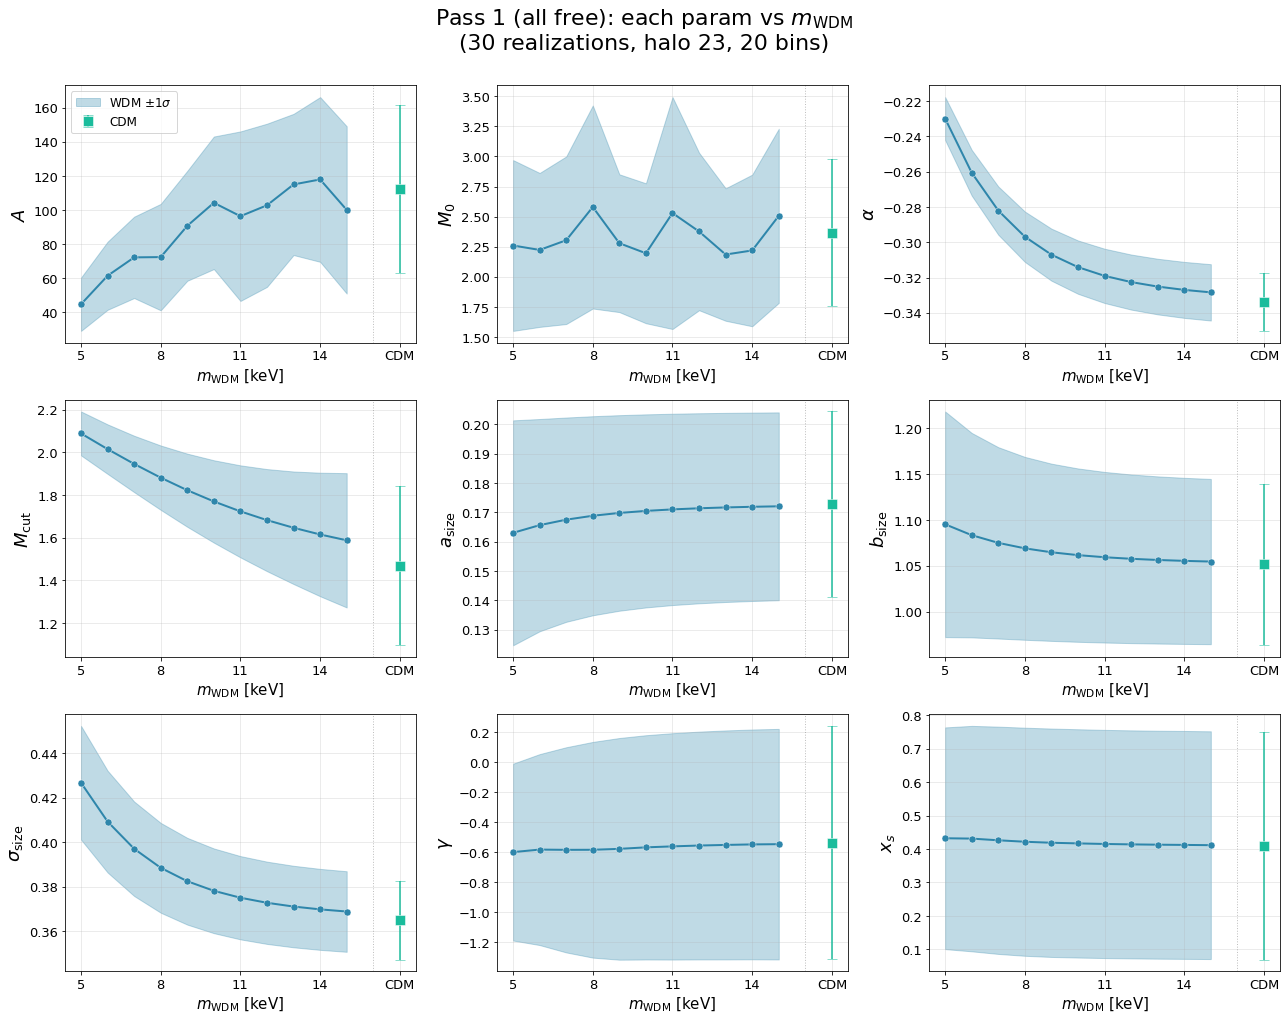


Cosmology            A        M_0      alpha      M_cut     a_size     b_size sigma_size      gamma        x_s
--------------------------------------------------------------------------------------------------------------
CDM            112.054      2.367     -0.334      1.468      0.173      1.051      0.365     -0.536      0.409
  (σ)           49.275      0.612      0.016      0.372      0.032      0.088      0.018      0.776      0.340
WDM_5keV        44.709      2.260     -0.230      2.089      0.163      1.095      0.427     -0.599      0.432
  (σ)           15.646      0.710      0.012      0.103      0.038      0.123      0.026      0.588      0.332
WDM_6keV        61.417      2.223     -0.261      2.016      0.166      1.083      0.409     -0.582      0.431
  (σ)           19.966      0.639      0.013      0.116      0.036      0.112      0.023      0.635      0.337
WDM_7keV        72.202      2.304     -0.282      1.946      0.167      1.075      0.397     -0.584      0.426


In [5]:
# %%
print("Cell Initiated")
# =============================================================================
# PLOT: All 9 Pass-1 params vs m_WDM — which knobs respond to WDM?
# 20-bin only. Mean ± 1σ band across 30 realizations. CDM shown as anchor.
# =============================================================================

def plot_params_vs_mwdm_clean(results_df, n_bins=20, output_path=None):
    """3×3 panel: each Pass-1 param's mean ± 1σ band vs m_WDM, CDM as anchor."""

    param_labels = [r'$A$', r'$M_0$', r'$\alpha$', r'$M_{\mathrm{cut}}$',
                    r'$a_{\mathrm{size}}$', r'$b_{\mathrm{size}}$',
                    r'$\sigma_{\mathrm{size}}$', r'$\gamma$', r'$x_s$']

    # x position for CDM anchor (right of the WDM range, with a gap)
    CDM_X = 17.0

    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    axes = axes.ravel()

    for idx, (ax, plabel) in enumerate(zip(axes, param_labels)):
        # --- WDM points: 5–15 keV ---
        x_plot, y_mean, y_std = [], [], []
        for cosmo in WDM_ONLY:
            m_wdm = COSMO_TO_MWDM[cosmo]
            sub = results_df[results_df['cosmo'] == cosmo]
            vals = [row['theta9_allfree'][idx] for _, row in sub.iterrows()
                    if hasattr(row['theta9_allfree'], '__len__')
                    and len(row['theta9_allfree']) == 9
                    and np.isfinite(row['theta9_allfree'][idx])]
            if len(vals) == 0:
                continue
            vals = np.array(vals)
            x_plot.append(m_wdm)
            y_mean.append(np.mean(vals))
            y_std.append(np.std(vals))

        x_plot = np.array(x_plot, dtype=float)
        y_mean = np.array(y_mean)
        y_std = np.array(y_std)

        ax.fill_between(x_plot, y_mean - y_std, y_mean + y_std,
                        alpha=0.3, color=MAIN_COLOR, label=r'WDM $\pm 1\sigma$')
        ax.plot(x_plot, y_mean, 'o-', color=MAIN_COLOR, lw=2, ms=7,
                markeredgecolor='white', markeredgewidth=0.4, zorder=4)

        # --- CDM anchor ---
        sub_cdm = results_df[results_df['cosmo'] == 'CDM']
        cdm_vals = [row['theta9_allfree'][idx] for _, row in sub_cdm.iterrows()
                    if hasattr(row['theta9_allfree'], '__len__')
                    and len(row['theta9_allfree']) == 9
                    and np.isfinite(row['theta9_allfree'][idx])]
        if len(cdm_vals) > 0:
            cdm_mean = np.mean(cdm_vals)
            cdm_std = np.std(cdm_vals)
            ax.errorbar([CDM_X], [cdm_mean], yerr=[cdm_std],
                        fmt='s', color=CDM_COLOR, ms=10, capsize=5, capthick=2,
                        markeredgecolor='white', markeredgewidth=0.5,
                        label='CDM', zorder=5)

        # Visual separator between WDM range and CDM anchor
        ax.axvline(16.0, color='gray', ls=':', lw=1, alpha=0.5)

        ax.set_ylabel(plabel, fontsize=18)
        ax.set_xlabel(r'$m_{\mathrm{WDM}}$ [keV]', fontsize=15)
        ax.set_xticks([5, 8, 11, 14, CDM_X])
        ax.set_xticklabels(['5', '8', '11', '14', 'CDM'])
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=13)

        if idx == 0:
            ax.legend(fontsize=12, loc='best')

    fig.suptitle(f'Pass 1 (all free): each param vs $m_{{\\mathrm{{WDM}}}}$\n'
                 f'(30 realizations, halo 23, {n_bins} bins)',
                 fontsize=22, y=1.01)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"  Saved: {output_path}")
    plt.show()
    plt.close()


# Run on 20-bin only
plot_params_vs_mwdm_clean(data[20]['results_df'], n_bins=20)

# Numeric summary: Pass 1 mean ± σ per param per cosmology
param_labels_plain = ['A', 'M_0', 'alpha', 'M_cut',
                       'a_size', 'b_size', 'sigma_size', 'gamma', 'x_s']
df = data[20]['results_df']

print(f"\n{'Cosmology':<11}", end='')
for p in param_labels_plain:
    print(f"{p:>11}", end='')
print()
print('-' * (11 + 11 * 9))

for cosmo in COSMO_NAMES:
    sub = df[df['cosmo'] == cosmo]
    means, stds = [], []
    for idx in range(9):
        vals = [row['theta9_allfree'][idx] for _, row in sub.iterrows()
                if hasattr(row['theta9_allfree'], '__len__')
                and len(row['theta9_allfree']) == 9
                and np.isfinite(row['theta9_allfree'][idx])]
        vals = np.array(vals)
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    print(f"{cosmo:<11}", end='')
    for m in means:
        print(f"{m:>11.3f}", end='')
    print()
    print(f"{'  (σ)':<11}", end='')
    for s in stds:
        print(f"{s:>11.3f}", end='')
    print()

print("Cell Completed")

Cell Initiated
  Saved: param_trends_3x3_20bin.png


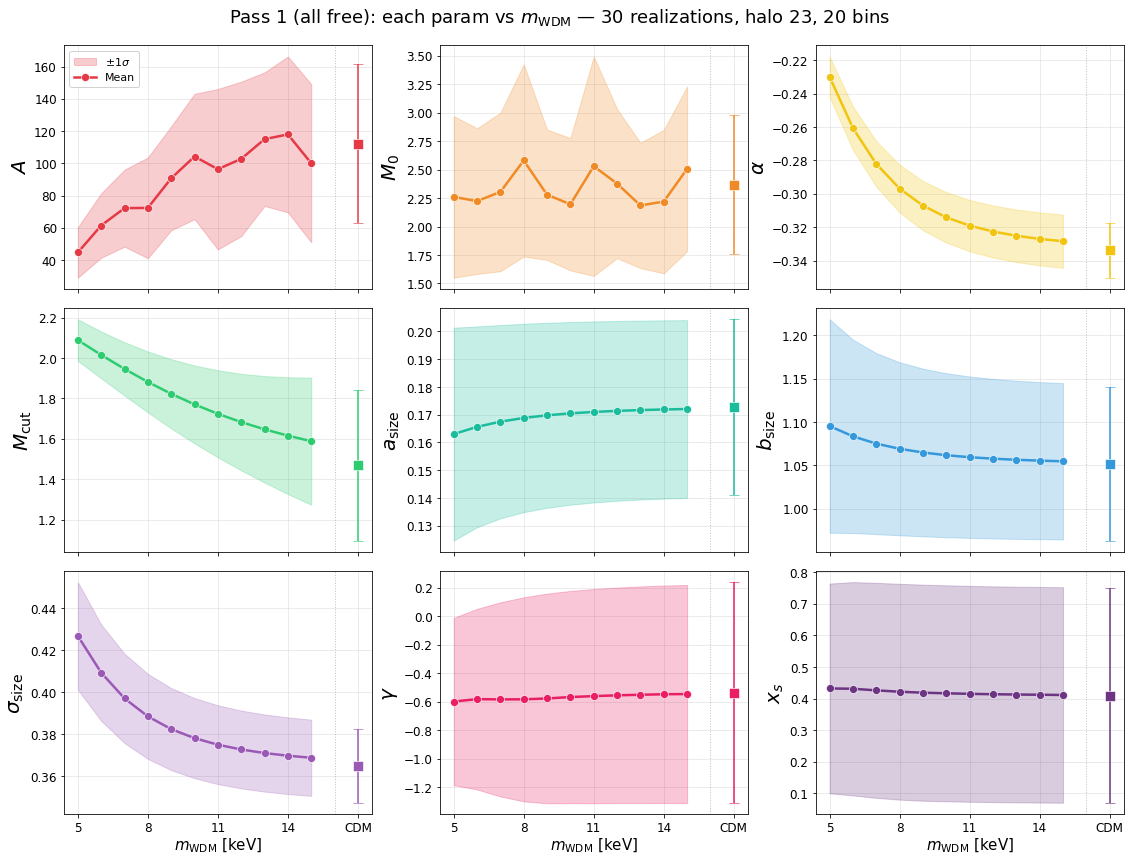

Cell Completed


In [9]:
# %%
print("Cell Initiated")
# =============================================================================
# PLOT: Pass-1 params vs m_WDM — 3×3 grid, shared x, minimal whitespace
# Mean line + 1σ band + CDM anchor. Retro rainbow, one color per param.
# =============================================================================

COLOR_BY_IDX = {
    0: '#E63946',   # A          — red
    1: '#F08A25',   # M_0        — orange
    2: '#F1C40F',   # alpha      — gold
    3: '#2ECC71',   # M_cut      — green
    4: '#1ABC9C',   # a_size     — teal
    5: '#3498DB',   # b_size     — blue
    6: '#9B59B6',   # sigma_size — purple
    7: '#E91E63',   # gamma      — pink
    8: '#6C3483',   # x_s        — deep violet
}

PARAM_LATEX = [r'$A$', r'$M_0$', r'$\alpha$', r'$M_{\mathrm{cut}}$',
               r'$a_{\mathrm{size}}$', r'$b_{\mathrm{size}}$',
               r'$\sigma_{\mathrm{size}}$', r'$\gamma$', r'$x_s$']

CDM_X = 17.0

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True)
axes = axes.ravel()

results_df = data[20]['results_df']

for idx, ax in enumerate(axes):
    color = COLOR_BY_IDX[idx]

    # WDM 5–15 keV
    x_plot, y_mean, y_std = [], [], []
    for cosmo in WDM_ONLY:
        m_wdm = COSMO_TO_MWDM[cosmo]
        sub = results_df[results_df['cosmo'] == cosmo]
        vals = [row['theta9_allfree'][idx] for _, row in sub.iterrows()
                if hasattr(row['theta9_allfree'], '__len__')
                and len(row['theta9_allfree']) == 9
                and np.isfinite(row['theta9_allfree'][idx])]
        if len(vals) == 0:
            continue
        vals = np.array(vals)
        x_plot.append(m_wdm)
        y_mean.append(np.mean(vals))
        y_std.append(np.std(vals))

    x_plot = np.array(x_plot, dtype=float)
    y_mean = np.array(y_mean)
    y_std = np.array(y_std)

    ax.fill_between(x_plot, y_mean - y_std, y_mean + y_std,
                    alpha=0.25, color=color, zorder=2, label=r'$\pm 1\sigma$')
    ax.plot(x_plot, y_mean, 'o-', color=color, lw=2.5, ms=8,
            markeredgecolor='white', markeredgewidth=0.6,
            zorder=4, label='Mean')

    # CDM anchor
    sub_cdm = results_df[results_df['cosmo'] == 'CDM']
    cdm_vals = [row['theta9_allfree'][idx] for _, row in sub_cdm.iterrows()
                if hasattr(row['theta9_allfree'], '__len__')
                and len(row['theta9_allfree']) == 9
                and np.isfinite(row['theta9_allfree'][idx])]
    if len(cdm_vals) > 0:
        cdm_vals = np.array(cdm_vals)
        ax.errorbar([CDM_X], [np.mean(cdm_vals)], yerr=[np.std(cdm_vals)],
                    fmt='s', color=color, ms=10, capsize=5, capthick=2,
                    markeredgecolor='white', markeredgewidth=0.6,
                    zorder=5)

    ax.axvline(16.0, color='gray', ls=':', lw=1, alpha=0.5)
    ax.set_ylabel(PARAM_LATEX[idx], fontsize=20, labelpad=4)
    ax.set_xticks([5, 8, 11, 14, CDM_X])
    ax.set_xticklabels(['5', '8', '11', '14', 'CDM'])
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=12)

    # Only bottom row gets x-axis label
    if idx >= 6:
        ax.set_xlabel(r'$m_{\mathrm{WDM}}$ [keV]', fontsize=15, labelpad=2)

    if idx == 0:
        ax.legend(fontsize=11, loc='best', framealpha=0.9)

fig.suptitle(f'Pass 1 (all free): each param vs $m_{{\\mathrm{{WDM}}}}$ — 30 realizations, halo 23, 20 bins',
             fontsize=18, y=0.995)
plt.subplots_adjust(left=0.07, right=0.99, top=0.95, bottom=0.06,
                    wspace=0.22, hspace=0.08)

output_path = 'param_trends_3x3_20bin.png'
plt.savefig(output_path, dpi=200, bbox_inches='tight')
print(f"  Saved: {output_path}")

plt.show()
plt.close()

print("Cell Completed")